# Neural Networks and Exchange Rate Forecasting

This notebook records three practice workflows: regression with a multilayer perceptron, binary classification with a deep neural network, and next-day exchange-rate forecasting with tree-based and recurrent models.

## Regression MLP for California Housing

**Practice goal.** Compare output-layer choices for a regression MLP and explore neural-network hyperparameters with Keras Tuner.

The California housing dataset is loaded with `sklearn.datasets.fetch_california_housing()`. The data are divided into training, validation, and test sets using fixed random seeds so the comparisons can be repeated.


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X = housing.data
y = housing.target

X_train_tmp, X_test, y_train_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_tmp, y_train_tmp, test_size=0.2, random_state=42)

### Output Activation Comparison

**Method.** Two regression MLPs use the same normalization layer, one hidden layer with 50 ReLU neurons, He initialization, the Nadam optimizer, and mean squared error loss. One model uses a ReLU output and the other uses a linear output. Both are trained for 30 epochs and compared with validation MSE.


**Implementation:**


In [2]:
tf.keras.utils.set_random_seed(67)

# normalization layer
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
norm_layer.adapt(X_train)

  super().__init__(**kwargs)


In [3]:
# output layer with ReLU activation

tf.keras.backend.clear_session()

model_relu = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(
        50,
        activation="relu",
        kernel_initializer="he_normal"
    ),
    tf.keras.layers.Dense(
        1,
        activation="relu",
        kernel_initializer="he_normal"
    )
])

model_relu.compile(
    loss="mse",
    optimizer=tf.keras.optimizers.Nadam()
)

history_relu = model_relu.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_valid, y_valid),
    verbose=0
)

val_mse_relu = model_relu.evaluate(X_valid, y_valid, verbose=0)
val_mse_relu

0.35764142870903015

In [4]:
# output layer with ReLU activation

tf.keras.backend.clear_session()

model_relu = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(
        50,
        activation="relu",
        kernel_initializer="he_normal"
    ),
    tf.keras.layers.Dense(
        1,
        activation="relu",
        kernel_initializer="he_normal"
    )
])

model_relu.compile(
    loss="mse",
    optimizer=tf.keras.optimizers.Nadam()
)

history_relu = model_relu.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_valid, y_valid),
    verbose=0
)

val_mse_relu = model_relu.evaluate(X_valid, y_valid, verbose=0)
val_mse_relu

0.37629756331443787

### Evaluation and Interpretation

For the model with a ReLU output layer, the validation MSE was **0.3576**. For the model without an output activation function, the validation MSE was **0.3763**. Since a lower MSE indicates better performance, the model with the ReLU output layer performed better in this experiment.

Although a linear output layer is more common for regression, the California housing target is non-negative. ReLU therefore provides a reasonable alternative because it restricts predictions to non-negative values. Based on the observed validation MSE, I selected the ReLU output model for this comparison.


### Hyperparameter Tuning with Keras Tuner

**Method.** A randomized search uses the first 5,000 training observations, 20 trials, and 20 epochs per trial. The objective is validation loss and the random seed is 42. The search space covers:

- one to five hidden layers
- one to 100 neurons per layer
- learning rates from $10^{-4}$ to $10^{-2}$ with log sampling
- $\ell_2$ regularization from $10^{-4}$ to $100$ with log sampling
- SGD with gradient clipping or Nadam

The tuned network retains a linear output layer and reports the best hyperparameter configuration found by the search.


**Implementation:**


In [2]:
import keras_tuner as kt
import tensorflow as tf
import numpy as np

tf.keras.utils.set_random_seed(67)

# use only the first 5000 training samples for randomized search
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

In [3]:
def build_model(hp):
    model = tf.keras.Sequential()
    
    norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
    norm_layer.adapt(X_train_small)
    model.add(norm_layer)
    
    n_hidden = hp.Int("n_hidden", 1, 5)
    
    learning_rate = hp.Float(
        "learning_rate",
        min_value=1e-4,
        max_value=1e-2,
        sampling="log"
    )
    
    l2_value = hp.Float(
        "l2_value",
        min_value=1e-4,
        max_value=100,
        sampling="log"
    )
    
    optimizer_name = hp.Choice("optimizer", ["sgd", "nadam"])
    
    for i in range(n_hidden):
        model.add(tf.keras.layers.Dense(
            hp.Int(f"n_neurons_{i+1}", 1, 100),
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=tf.keras.regularizers.l2(l2_value)
        ))
    
    # output layer: no activation function
    model.add(tf.keras.layers.Dense(1))
    
    if optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            clipnorm=1.0
        )
    else:
        optimizer = tf.keras.optimizers.Nadam(
            learning_rate=learning_rate
        )
    
    model.compile(
        loss="mse",
        optimizer=optimizer
    )
    
    return model

In [5]:
import tempfile

tf.keras.backend.clear_session()

tuner_dir = tempfile.mkdtemp()
print("Tuner directory:", tuner_dir)

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    seed=42,
    overwrite=True,
    directory=tuner_dir,
    project_name="clean_mlp_project"
)

  super().__init__(**kwargs)


In [8]:
tuner.search(
    X_train_small,
    y_train_small,
    epochs=20,
    validation_data=(X_valid, y_valid),
    verbose=1
)

Trial 20 Complete [00h 00m 06s]
val_loss: 0.47537118196487427

Best val_loss So Far: 0.4085060656070709
Total elapsed time: 00h 01m 52s


In [9]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters:")
for key, value in best_hp.values.items():
    print(key, ":", value)

Best hyperparameters:
n_hidden : 1
learning_rate : 0.008547485565344062
l2_value : 0.00018005047916780728
optimizer : nadam
n_neurons_1 : 23
n_neurons_2 : 31
n_neurons_3 : 50
n_neurons_4 : 93


In [10]:
best_model = tuner.get_best_models(1)[0]

best_val_mse = best_model.evaluate(X_valid, y_valid, verbose=0)
print("Best validation MSE:", best_val_mse)

Best validation MSE: 0.4085060656070709


  saveable.load_own_variables(weights_store.get(inner_path))


## Binary Classification DNN for Bank Marketing

**Practice goal.** Build a deep neural network that predicts whether a Portuguese bank marketing contact results in a term-deposit subscription.

The target is `response_binary`. The preprocessing workflow standardizes numerical features, one-hot encodes nominal categories, ordinal-encodes education, and represents day and month as cyclical features. The separately distributed bank-marketing dataset is loaded from `../data/bank_cleaned.csv`.


In [14]:
df = pd.read_csv("../data/bank_cleaned.csv")

month_dict = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
              "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}
day_rad = (df["day"] - 1) * (2 * np.pi / 31)
month_rad = (df["month"].replace(month_dict).astype(float) - 1) * (2 * np.pi / 12)
df["day_sin"] = np.sin(day_rad)
df["day_cos"] = np.cos(day_rad)
df["month_sin"] = np.sin(month_rad)
df["month_cos"]  = np.cos(month_rad)
df.drop(columns=["Unnamed: 0", "month", "day", "response"], inplace=True)
df.head()

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,poutcome,response_binary,day_sin,day_cos,month_sin,month_cos
0,58,management,married,tertiary,no,2143,yes,no,4.35,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5
1,44,technician,single,secondary,no,29,yes,no,2.52,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5
2,33,entrepreneur,married,secondary,no,2,yes,yes,1.27,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5
3,35,management,married,tertiary,no,231,yes,no,2.32,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5
4,28,management,single,tertiary,no,447,yes,yes,3.62,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5


In [15]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

train_set_tmp, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set, valid_set = train_test_split(train_set_tmp, test_size=0.2, random_state=42)

X_train_raw = train_set.drop("response_binary", axis=1).copy()
y_train = train_set["response_binary"].copy()
X_valid_raw = valid_set.drop("response_binary", axis=1).copy()
y_valid = valid_set["response_binary"].copy()
X_test_raw = test_set.drop("response_binary", axis=1).copy()
y_test = test_set["response_binary"].copy()

num_attribs = list(X_train_raw._get_numeric_data().columns)
cat_attribs = list(set(X_train_raw.columns) - set(num_attribs))

cat_attribs_ord = ['default', 'housing', 'loan']
cat_attribs_hot = ['job', 'marital', 'education', 'poutcome']

full_pipeline = ColumnTransformer([
        ("num", StandardScaler(), num_attribs),
        ("cat_hot", OneHotEncoder(), cat_attribs_hot),
        ("cat_ord", OrdinalEncoder(categories=[['no','yes'],['no','yes'],['no','yes']]), cat_attribs_ord)
    ])

X_train = full_pipeline.fit_transform(X_train_raw)
X_valid = full_pipeline.transform(X_valid_raw)
X_test = full_pipeline.transform(X_test_raw)

### Architecture and Evaluation Design

**Method.** The classifier uses four hidden layers with 100 neurons each, He initialization, and Swish activation. A single sigmoid output represents the estimated success probability. Binary cross-entropy is used as the loss, and AUC is tracked because the target is binary and imbalanced. The training-set success proportion provides a simple class-balance check.


**Implementation:**


In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf

# proportion of successes in the training set
success_prop = y_train.mean()

print("Proportion of successes in training data:", success_prop)

Proportion of successes in training data: 0.11168075907717029


In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    
    tf.keras.layers.Dense(
        100,
        activation="swish",
        kernel_initializer="he_normal"
    ),
    
    tf.keras.layers.Dense(
        100,
        activation="swish",
        kernel_initializer="he_normal"
    ),
    
    tf.keras.layers.Dense(
        100,
        activation="swish",
        kernel_initializer="he_normal"
    ),
    
    tf.keras.layers.Dense(
        100,
        activation="swish",
        kernel_initializer="he_normal"
    ),
    
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

### Architecture Rationale and Observation

The four-layer DNN treats `response_binary` as a binary outcome. Swish provides a smooth nonlinear activation, while He initialization is a practical choice for deep networks with ReLU-like activations. The sigmoid output maps predictions to probabilities, and binary cross-entropy matches the binary target.

AUC complements the loss by measuring ranking performance across classification thresholds. The success proportion is calculated with `y_train.mean()` because the target is encoded as zero and one.


### Learning-Rate Scheduling and Overfitting Check

**Method.** The DNN is trained for 30 epochs with Nesterov accelerated gradient, implemented as SGD with `momentum=0.9` and `nesterov=True`. An exponential schedule starts at `lr0=0.01` with `s=20`. Training and validation learning curves are compared for signs of overfitting after resetting the TensorFlow session.


In [18]:
def reset_session(seed=67):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    tf.keras.backend.clear_session()
    
def exponential_decay(lr0, s):
    return lambda epoch: lr0 * 0.1**(epoch / s)

In [19]:
reset_session()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    
    tf.keras.layers.Dense(
        100,
        activation="swish",
        kernel_initializer="he_normal"
    ),
    
    tf.keras.layers.Dense(
        100,
        activation="swish",
        kernel_initializer="he_normal"
    ),
    
    tf.keras.layers.Dense(
        100,
        activation="swish",
        kernel_initializer="he_normal"
    ),
    
    tf.keras.layers.Dense(
        100,
        activation="swish",
        kernel_initializer="he_normal"
    ),
    
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [20]:
# NAG optimizer
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

model.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

In [21]:
# Learning rate schedule
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    exponential_decay(lr0=0.01, s=20)
)

# train 30 epochs
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_valid, y_valid),
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/30
817/817 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - auc: 0.8807 - loss: 0.2417 - val_auc: 0.9007 - val_loss: 0.2234 - learning_rate: 0.0100
Epoch 2/30
817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9061 - loss: 0.2185 - val_auc: 0.9055 - val_loss: 0.2185 - learning_rate: 0.0089
Epoch 3/30
817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9125 - loss: 0.2127 - val_auc: 0.9091 - val_loss: 0.2156 - learning_rate: 0.0079
Epoch 4/30
817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9167 - loss: 0.2086 - val_auc: 0.9117 - val_loss: 0.2136 - learning_rate: 0.0071
Epoch 5/30
817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9199 - loss: 0.2053 - val_auc: 0.9132 - val_loss: 0.2121 - learning_rate: 0.0063
Epoch 6/30
817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9226 - loss: 0.2024 - val_auc: 0.9146 - val_loss: 0.2111 - learning_rate: 0.0056
Epoch 7/30
817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9250 - loss: 0.2000 - val_auc: 0.9159 - val_loss: 0.2103 - learning_rate: 0.0050
Epoch 

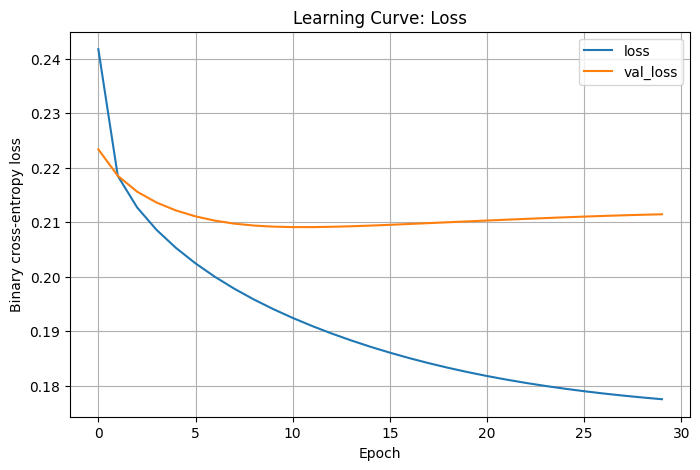

In [22]:
# learning curve：loss

import matplotlib.pyplot as plt
history_df = pd.DataFrame(history.history)

history_df[["loss", "val_loss"]].plot(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Learning Curve: Loss")
plt.grid(True)
plt.show()

In [23]:
val_loss, val_auc = model.evaluate(X_valid, y_valid, verbose=0)

print("Validation loss:", val_loss)
print("Validation AUC:", val_auc)

Validation loss: 0.21145009994506836
Validation AUC: 0.9170898795127869


### Learning Curve Interpretation

The training loss continues to decrease, while the validation loss decreases initially and then rises slightly. This suggests mild overfitting in the later epochs. The recorded final validation loss is about **0.2115**, and validation AUC is about **0.9171**.

The model performs reasonably well on the validation set, but the later separation between the curves indicates that additional regularization or earlier stopping could be useful in a future iteration.


**Implementation:**


## Exchange Rate Forecasting with Machine Learning

**Practice goal.** Compare a random forest and a recurrent neural network for next-day forecasting of the Japan/U.S. foreign exchange rate (`DEXJPUS`).

Daily observations from January 1990 through January 2023 are loaded from the public FRED CSV endpoint. This section requires internet access when the data are retrieved.


In [24]:
import pandas as pd

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXJPUS"

data = pd.read_csv(
    url,
    parse_dates=["observation_date"],
    na_values="."
)

data = data.rename(columns={"observation_date": "DATE"})
data = data.set_index("DATE")

data = data.loc["1990-01-01":"2023-01-01"]

data.head()

,DEXJPUS
DATE,
1990-01-01,NaN
1990-01-02,146.25
1990-01-03,145.70
1990-01-04,143.37
1990-01-05,143.82


### Supervised Window Construction

**Method.** Observations before 2010 form the training set, January 2010 through December 2015 forms the validation set, and later observations form the test set. Each supervised example uses the current exchange rate and the previous nine observations to predict the next day's value.


**Implementation:**


In [29]:
import numpy as np
import pandas as pd

data["DEXJPUS"] = pd.to_numeric(data["DEXJPUS"], errors="coerce")

data = data.dropna(subset=["DEXJPUS"])

series = data["DEXJPUS"]

def make_supervised(series, window=10):
    X = []
    y = []
    dates = []
    
    values = series.values
    index = series.index
    
    for i in range(window - 1, len(values) - 1):
        X.append(values[i - window + 1:i + 1])
        y.append(values[i + 1])
        dates.append(index[i + 1])
    
    return np.array(X), np.array(y).reshape(-1, 1), pd.DatetimeIndex(dates)

X, y, dates = make_supervised(series, window=10)

In [30]:
train_mask = dates < "2010-01-01"
valid_mask = (dates >= "2010-01-01") & (dates <= "2015-12-31")
test_mask = dates > "2015-12-31"

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(5023, 10) (5023, 1)
(1504, 10) (1504, 1)
(1747, 10) (1747, 1)


### Random Forest Forecasting Baseline

**Evaluation.** A random forest regressor predicts the next-day exchange rate. Test performance is measured with mean squared error and directional accuracy. Directional accuracy compares the sign of the predicted one-day change with the sign of the observed change.


In [27]:
movement_test = X_test[:,-1] < y_test.ravel()

**Implementation:**


In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, accuracy_score

rf_reg = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train.ravel())

y_pred_rf = rf_reg.predict(X_test)

mse_rf = mean_squared_error(y_test.ravel(), y_pred_rf)

movement_test = X_test[:, -1] < y_test.ravel()
movement_pred_rf = X_test[:, -1] < y_pred_rf

acc_rf = accuracy_score(movement_test, movement_pred_rf)

print("Random Forest Test MSE:", mse_rf)
print("Random Forest Direction Accuracy:", acc_rf)

Random Forest Test MSE: 0.5251923771869653
Random Forest Direction Accuracy: 0.5174585002862049


### Recurrent Neural Network Forecast

**Method.** A deep RNN with two recurrent layers of 20 neurons and one dense output neuron is trained for 100 epochs with the Nadam optimizer. The validation learning curve is used to assess convergence and overfitting, while test MSE and directional accuracy are compared with the random forest baseline.


**Implementation:**


In [32]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
import matplotlib.pyplot as plt

def reset_session(seed=67):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)

In [33]:
# Standardize data

scaler = StandardScaler()

scaler.fit(X_train.reshape(-1, 1))

X_train_scaled = scaler.transform(X_train.reshape(-1, 1)).reshape(-1, 10, 1)
X_valid_scaled = scaler.transform(X_valid.reshape(-1, 1)).reshape(-1, 10, 1)
X_test_scaled = scaler.transform(X_test.reshape(-1, 1)).reshape(-1, 10, 1)

y_train_scaled = scaler.transform(y_train).ravel()
y_valid_scaled = scaler.transform(y_valid).ravel()

In [34]:
# Build RNN model

reset_session()

rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10, 1)),
    tf.keras.layers.SimpleRNN(20, return_sequences=True),
    tf.keras.layers.SimpleRNN(20),
    tf.keras.layers.Dense(1)
])

rnn_model.compile(
    loss="mse",
    optimizer=tf.keras.optimizers.Nadam()
)

In [35]:
# Train 100 epochs

history = rnn_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    validation_data=(X_valid_scaled, y_valid_scaled),
    verbose=1
)

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1211 - val_loss: 0.0228
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0089 - val_loss: 0.0072
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0062 - val_loss: 0.0048
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053 - val_loss: 0.0041
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0048 - val_loss: 0.0039
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - val_loss: 0.0038
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042 - val_loss: 0.0039
Epoch 9/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 10/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 11/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 12/100
157/157 ━━━━━━━━━━━━━━━━━━━━

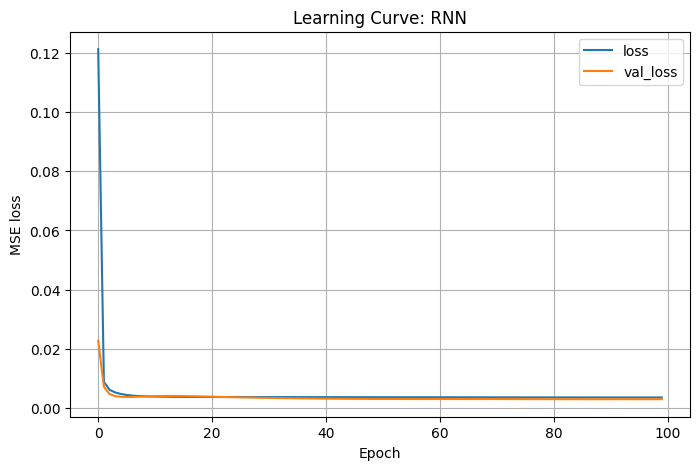

In [36]:
# Learning curve

history_df = pd.DataFrame(history.history)

history_df[["loss", "val_loss"]].plot(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Learning Curve: RNN")
plt.grid(True)
plt.show()

In [37]:
# Evaluate on test set

y_pred_rnn_scaled = rnn_model.predict(X_test_scaled)

y_pred_rnn = scaler.inverse_transform(y_pred_rnn_scaled).ravel()

mse_rnn = mean_squared_error(y_test.ravel(), y_pred_rnn)

movement_test = X_test[:, -1] < y_test.ravel()
movement_pred_rnn = X_test[:, -1] < y_pred_rnn

acc_rnn = accuracy_score(movement_test, movement_pred_rnn)

print("RNN Test MSE:", mse_rnn)
print("RNN Direction Accuracy:", acc_rnn)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
RNN Test MSE: 0.5501178900263024
RNN Direction Accuracy: 0.4985689753863766


### RNN Result Interpretation

The RNN converges quickly. Training and validation loss both fall sharply in the first few epochs and then remain stable, with no strong separation between the two curves.

The recorded test MSE is about **0.5501**, and directional accuracy is about **0.4986**, which is close to 50%. In this experiment, the RNN does not predict the direction of the next exchange-rate movement better than chance, despite stable training and validation curves.
